In [ ]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from torchvision.models import resnet18, ResNet18_Weights
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import joblib
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import classification_report
import time

batch_size = 128
num_classes = 10
epochs = 12

history = {
    'train_loss': [],
    'test_loss': [],
    'test_accuracy': []
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

weights = ResNet18_Weights.DEFAULT

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=weights.transforms().mean,
        std=weights.transforms().std
    )
])

data_dir = '../../'
train_dataset = datasets.MNIST(root=data_dir, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=data_dir, train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


model = resnet18(weights=ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False  # Freeze all layers except the final fully connected layer
    
model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)

optimizer = optim.Adam(
    model.fc.parameters(), 
    lr=0.001
) # Fine-tuning only the final fully connected layer.

# optimizer = optim.Adam(
#     model.parameters(),
#     lr=0.001
# ) # Fine-tuning the entire network. All layers are trainable.


criterion = nn.CrossEntropyLoss() # ResNet does not return log probabilities. It returns raw logits.

print(model.fc)  # Print the final fully connected layer to verify the output features
print('Total parameters:', sum(p.numel() for p in model.parameters()))

Using device: cuda
Linear(in_features=512, out_features=10, bias=True)
Total parameters: 11181642


In [4]:
def train(epoch):
    epoch_loss = 0
    model.train()
    start_time = time.time()
    for batch_idx, (data, target) in enumerate(train_loader, start=1):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}]'
                  f'  Loss: {loss.item():.4f}')
        epoch_loss += loss.item()
    epoch_loss /= len(train_loader)
    end_time = time.time()
    return end_time - start_time, epoch_loss

def test():
    model.eval()
    test_loss = 0
    correct = 0

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            all_predictions.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    test_loss /= len(test_loader.dataset)
    accuracy = 100.0 * correct / len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n')

    return {
        'loss': test_loss,
        'accuracy': accuracy,
        'targets': all_targets,
        'predictions': all_predictions
    }

for epoch in range(1, epochs + 1):
    training_time, train_loss = train(epoch)
    results = test()

    history['train_loss'].append(train_loss)
    history['test_loss'].append(results['loss'])
    history['test_accuracy'].append(results['accuracy'])
cm = confusion_matrix(results['targets'], results['predictions'])
report = classification_report(
    results['targets'],
    results['predictions'],
    output_dict=True
)


Train Epoch: 1 [12800/60000]  Loss: 0.5569
Train Epoch: 1 [25600/60000]  Loss: 0.3979
Train Epoch: 1 [38400/60000]  Loss: 0.2485
Train Epoch: 1 [51200/60000]  Loss: 0.2855

Test set: Average loss: 0.2289, Accuracy: 9418/10000 (94.18%)

Train Epoch: 2 [12800/60000]  Loss: 0.3204
Train Epoch: 2 [25600/60000]  Loss: 0.1966
Train Epoch: 2 [38400/60000]  Loss: 0.2750
Train Epoch: 2 [51200/60000]  Loss: 0.2050

Test set: Average loss: 0.1686, Accuracy: 9539/10000 (95.39%)

Train Epoch: 3 [12800/60000]  Loss: 0.2060
Train Epoch: 3 [25600/60000]  Loss: 0.1691
Train Epoch: 3 [38400/60000]  Loss: 0.1319
Train Epoch: 3 [51200/60000]  Loss: 0.1095

Test set: Average loss: 0.1466, Accuracy: 9568/10000 (95.68%)

Train Epoch: 4 [12800/60000]  Loss: 0.0938
Train Epoch: 4 [25600/60000]  Loss: 0.1389
Train Epoch: 4 [38400/60000]  Loss: 0.1988
Train Epoch: 4 [51200/60000]  Loss: 0.1007

Test set: Average loss: 0.1446, Accuracy: 9551/10000 (95.51%)

Train Epoch: 5 [12800/60000]  Loss: 0.0760
Train Epoch: 

In [5]:
parameter_count = sum(p.numel() for p in model.parameters())

experiment = {
    'name': 'ResNet18 Transfer Learning',
    'optimizer': optimizer.__class__.__name__,
    'batch_size': batch_size,
    'epochs': epochs,
    'parameter_count': parameter_count,
    'history': history,
    'accuracy': report['accuracy'],
    'precision': report['weighted avg']['precision'],
    'recall': report['weighted avg']['recall'],
    'f1': report['weighted avg']['f1-score'],
    'classification_report': report,
    'confusion_matrix': cm,
    'duration': training_time,  
    'architecture': str(model),
    'learning_rate': optimizer.param_groups[0]['lr']  # Assuming a single parameter group
}

In [7]:
joblib.dump(experiment, '../../dictionary/resnet18_experiment.pkl')

torch.save(model.state_dict(), '../../model/resnet18_model.pt')

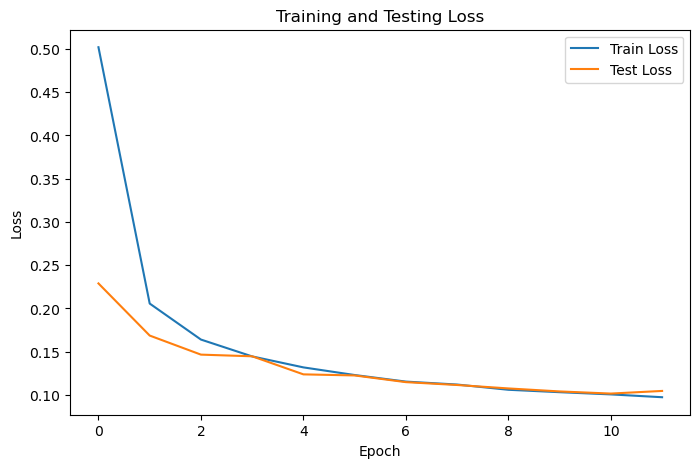

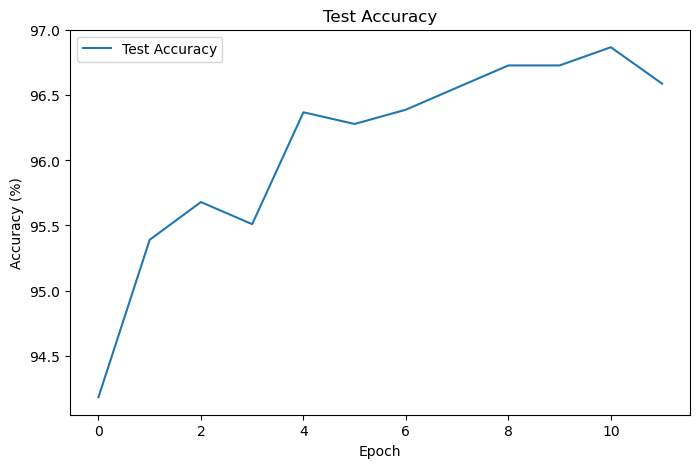

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing Loss')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(history['test_accuracy'], label='Test Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy')
plt.legend()
plt.show()

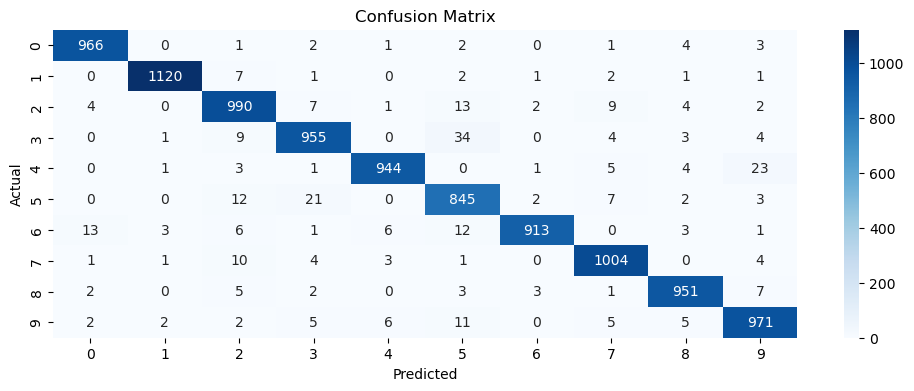

In [9]:
plt.figure(figsize=(12, 4))

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', cmap='Blues',
    xticklabels=range(num_classes), 
    yticklabels=range(num_classes)
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Confusion Matrix')
plt.show()

In [10]:
for name, param in model.named_parameters():
    print(name, param.requires_grad)

conv1.weight False
bn1.weight False
bn1.bias False
layer1.0.conv1.weight False
layer1.0.bn1.weight False
layer1.0.bn1.bias False
layer1.0.conv2.weight False
layer1.0.bn2.weight False
layer1.0.bn2.bias False
layer1.1.conv1.weight False
layer1.1.bn1.weight False
layer1.1.bn1.bias False
layer1.1.conv2.weight False
layer1.1.bn2.weight False
layer1.1.bn2.bias False
layer2.0.conv1.weight False
layer2.0.bn1.weight False
layer2.0.bn1.bias False
layer2.0.conv2.weight False
layer2.0.bn2.weight False
layer2.0.bn2.bias False
layer2.0.downsample.0.weight False
layer2.0.downsample.1.weight False
layer2.0.downsample.1.bias False
layer2.1.conv1.weight False
layer2.1.bn1.weight False
layer2.1.bn1.bias False
layer2.1.conv2.weight False
layer2.1.bn2.weight False
layer2.1.bn2.bias False
layer3.0.conv1.weight False
layer3.0.bn1.weight False
layer3.0.bn1.bias False
layer3.0.conv2.weight False
layer3.0.bn2.weight False
layer3.0.bn2.bias False
layer3.0.downsample.0.weight False
layer3.0.downsample.1.weight Fa